## Setup

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("style.mplstyle")
from preprocessing import get_models_and_soups_df
from scipy.stats import spearmanr, pearsonr

In [14]:
soups, models_df = get_models_and_soups_df()
soups['acc_gain_vs_best_parent'] = soups['clean_accuracy'] - soups[['clean_accuracy_a', 'clean_accuracy_b']].max(axis=1)

In [15]:
soups.columns

Index(['key_a', 'key_b', 'epoch_a', 'variant_a', 'epoch_b', 'variant_b',
       'shared_epochs', 'clean_accuracy', 'clean_loss', 'corrupted_accuracy',
       'corrupted_loss', 'clean_accuracy_permuted', 'clean_loss_permuted',
       'l2_distance', 'cosine_similarity', 'cka_logits', 'mse_logits',
       'kl_logits', 'cka_features', 'clean_loss_a', 'clean_accuracy_a',
       'clean_loss_b', 'clean_accuracy_b', 'corrupted_loss_a',
       'corrupted_loss_b', 'corrupted_accuracy_a', 'corrupted_accuracy_b',
       'soup_gain', 'permutated_gain', 'corrupted_gain',
       'acc_gain_vs_best_parent'],
      dtype='object')

## CDF over Soup Accuracies

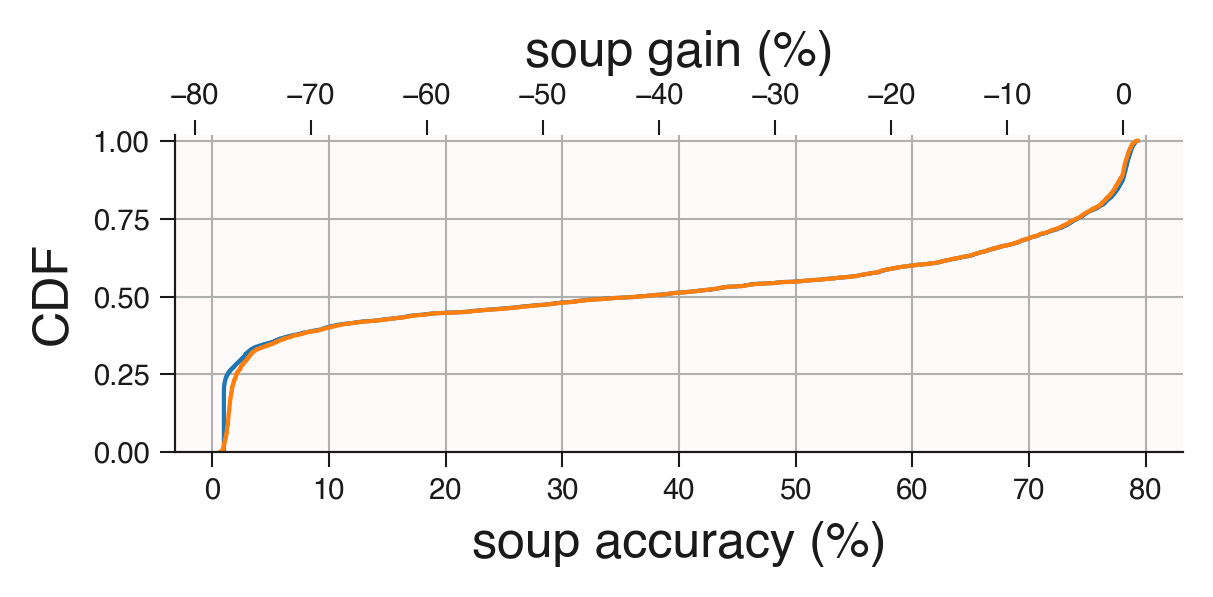

In [ ]:
# clean accuracy CDF
g1 = soups['clean_accuracy'].dropna().to_numpy()
g1_sorted = np.sort(g1)
cdf1 = np.arange(1, g1_sorted.size + 1) / g1_sorted.size

# gain CDF
g2 = soups['acc_gain_vs_best_parent'].dropna().to_numpy()
g2_sorted = np.sort(g2)
cdf2 = np.arange(1, g2_sorted.size + 1) / g2_sorted.size

fig, ax1 = plt.subplots(figsize=(4,2))

# left axis (accuracy)
ax1.plot(g1_sorted, cdf1, color='C0', linewidth=1)
ax1.set_xlabel('soup accuracy (%)', fontsize=12)
ax1.set_ylabel('CDF', fontsize=12)
ax1.set_ylim(0, 1.02)
ax1.grid(True)

# top axis (gain)
ax2 = ax1.twiny()
ax2.plot(g2_sorted, cdf2, color='C1', linewidth=1)
ax2.set_xlabel('soup gain (%)', fontsize=12)
ax2.grid(False)

plt.tight_layout()
plt.savefig('../iclr_report/figures/accuracy_and_gain_cdf.pdf')
plt.show()

## Soup accuracy vs gain

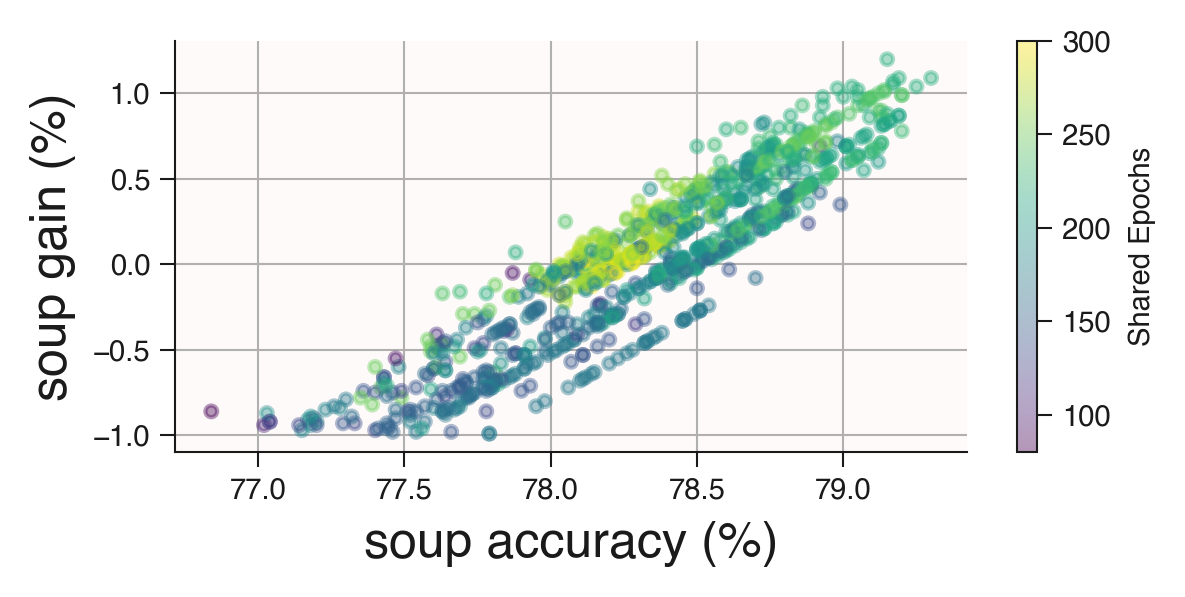

In [41]:
from scipy.stats import spearmanr

# accuracy vs gain
mask = soups['acc_gain_vs_best_parent'] > -1

x = soups.loc[mask, 'clean_accuracy'].to_numpy()
y = soups.loc[mask, 'acc_gain_vs_best_parent'].to_numpy()
c = soups.loc[mask, 'shared_epochs']

# drop NaNs
valid = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(c)
x, y, c = x[valid], y[valid], c[valid]

# Spearman correlation
rho, pval = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(4,2))
sc = ax.scatter(x, y, c=c, s=8, alpha=0.4)

ax.set_xlabel('soup accuracy (%)', fontsize=12)
ax.set_ylabel('soup gain (%)', fontsize=12)

# title + subtitle
# fig.suptitle('Accuracy vs Gain', fontsize=12)
# ax.set_title(f"Spearman $ρ$ = {rho:.2f}", fontsize=10)

# colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Shared Epochs')

plt.tight_layout()
plt.savefig('../iclr_report/figures/acc_vs_gain.pdf')
plt.show()